# Lab Assignment: Probability Distributions and Data Visualization
**Name:** Yesha Pandya  
**Enrolment Number:** 23BT04175  
**Div:** A **Batch:** C  

**Aim:**  
To generate and compare multiple probability distributions using NumPy and SciPy, analyze their statistical properties, and determine their suitability for synthetic AI dataset generation.

**Objectives:**  
1. Generate Normal, Uniform, Poisson, Exponential, and Log-normal distributions.
2. Compare statistical properties.
3. Visualize Probability Density Function (PDF).
4. Identify suitable distributions for different AI applications.

**Problem Statement:**  
A Generative AI company wants to create synthetic datasets for training machine learning models. Different features follow different statistical distributions. Generate five distributions and compare their behavior.

In [1]:
# Import core libraries and modules
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set visual style for seaborn
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## **1. Generate Synthetic Datasets**
We will generate 10,000 samples for each of the five required distributions.
- **Normal:** Centered at 0, standard deviation of 1.
- **Uniform:** Bounded between 0 and 10.
- **Poisson:** Lambda (rate) of 3.
- **Exponential:** Scale of 1.0.
- **Lognormal:** Mean of 0, standard deviation of 1.

In [2]:
# Number of samples
N = 10000

# Set random seed for reproducibility
np.random.seed(42)

# Generating distributions
data_normal = np.random.normal(loc=0.0, scale=1.0, size=N)
data_uniform = np.random.uniform(low=0.0, high=10.0, size=N)
data_poisson = np.random.poisson(lam=3.0, size=N)
data_exponential = np.random.exponential(scale=1.0, size=N)
data_lognormal = np.random.lognormal(mean=0.0, sigma=1.0, size=N)

# Dictionary to hold the generated data
distributions = {
    "Normal": data_normal,
    "Uniform": data_uniform,
    "Poisson": data_poisson,
    "Exponential": data_exponential,
    "Lognormal": data_lognormal
}
print("Data generation complete. 10,000 samples created for each distribution.")

Data generation complete. 10,000 samples created for each distribution.


## **2. Statistical Analysis**
We'll define a reusable function that calculates the Mean, Median, Mode, Variance, Standard Deviation, Skewness, and Kurtosis using NumPy and SciPy (to keep our code modular).

In [3]:
def calculate_statistics(data):
    """
    Calculates key statistical properties of a given dataset.
    """
    mean_val = np.mean(data)
    median_val = np.median(data)

    # SciPy mode returns an object; we extract the first mode value
    mode_result = stats.mode(data, keepdims=True)
    mode_val = mode_result.mode[0]

    var_val = np.var(data)
    std_val = np.std(data)
    skew_val = stats.skew(data)
    kurt_val = stats.kurtosis(data)

    return {
        "Mean": mean_val,
        "Median": median_val,
        "Mode": mode_val,
        "Variance": var_val,
        "Std Dev": std_val,
        "Skewness": skew_val,
        "Kurtosis": kurt_val
    }

### **2.1 Displaying Statistical Properties**
Iterate through our generated datasets, apply our statistics function, and display the results in a clean pandas DataFrame.

In [4]:
# Calculate stats for all distributions
stats_results = {}
for name, data in distributions.items():
    stats_results[name] = calculate_statistics(data)

# Convert to DataFrame for a beautiful tabular display
df_stats = pd.DataFrame(stats_results).T
display(df_stats)

,Mean,Median,Mode,Variance,Std Dev,Skewness,Kurtosis
Normal,-0.002136,-0.002595,-3.922400,1.006836,1.003412,0.001964,0.026479
Uniform,5.071346,5.112693,0.000481,8.380525,2.894914,-0.034060,-1.193417
Poisson,2.990300,3.000000,3.000000,2.950606,1.717733,0.590362,0.459967
Exponential,0.989126,0.695708,0.000171,0.942155,0.970647,1.963031,5.739477
Lognormal,1.655488,1.025943,0.019359,4.487760,2.118433,5.242079,53.781172


## **3. Visualization**
We need to visualize the Histogram, PDF Curve (Kernel Density Estimate), and Box Plot for each distribution.

We'll create a modular plotting function to handle this for any given array of data.

In [5]:
def plot_distribution(data, title, color):
    """
    Plots a Histogram with PDF curve (KDE) and a Box plot for the given data.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Histogram + PDF (KDE)
    sns.histplot(data, kde=True, stat="density", color=color, ax=axes[0], bins=50)
    axes[0].set_title(f"{title} Distribution - Histogram and PDF")
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Density")

    # Plot 2: Box Plot
    sns.boxplot(x=data, color=color, ax=axes[1])
    axes[1].set_title(f"{title} Distribution - Box Plot")
    axes[1].set_xlabel("Value")

    plt.tight_layout()
    plt.show()

### **3.1 Visualize Normal and Uniform Distributions**

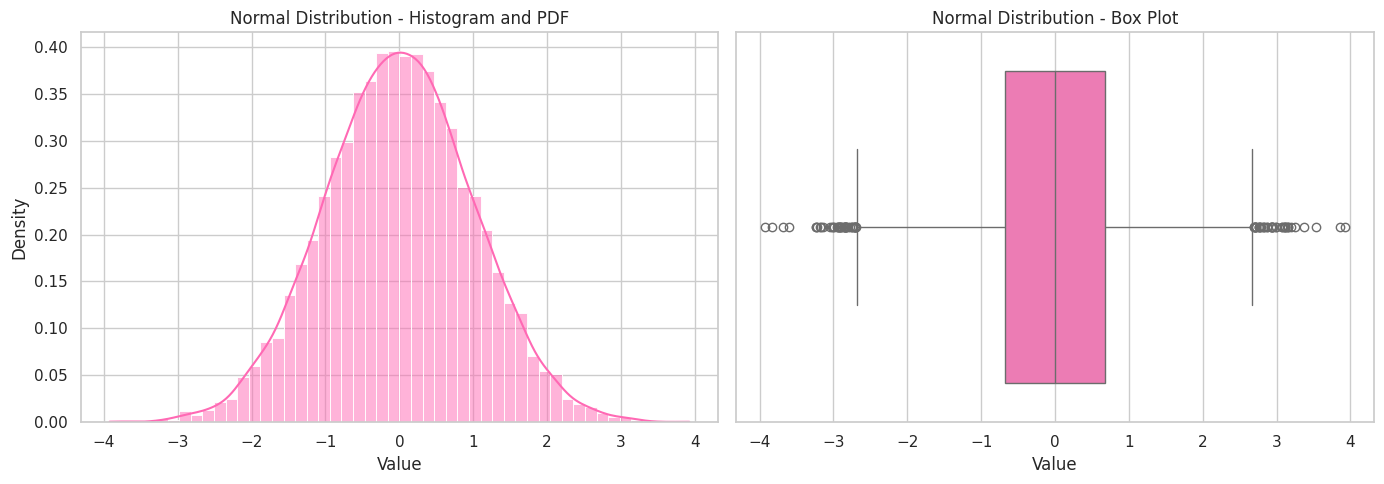

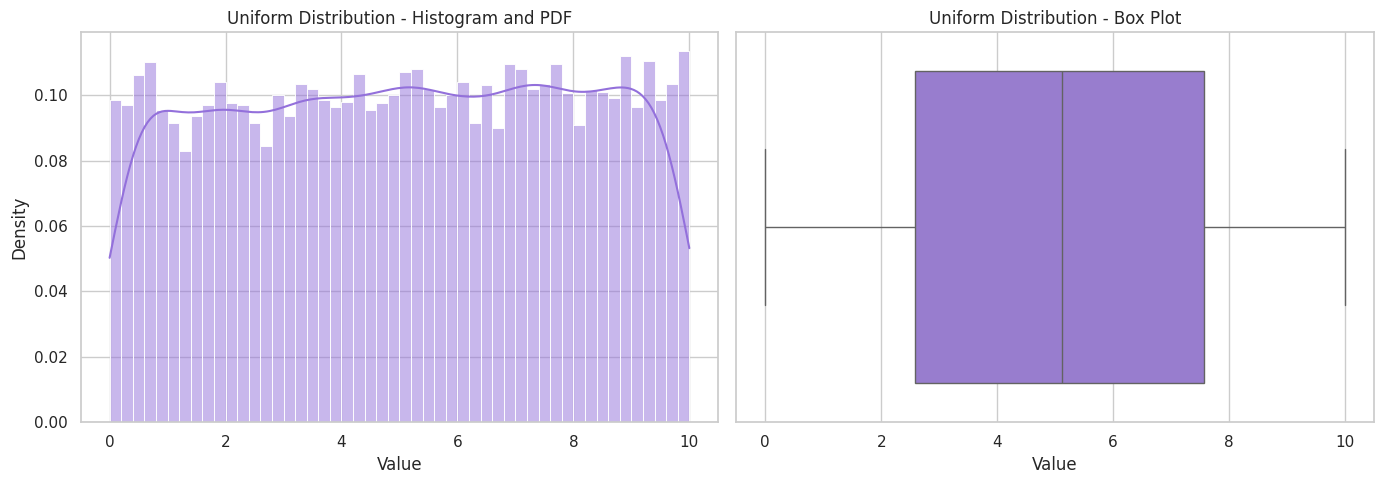

In [6]:
plot_distribution(distributions["Normal"], "Normal", "hotpink")
plot_distribution(distributions["Uniform"], "Uniform", "mediumpurple")

### **3.2 Visualize Poisson and Exponential Distributions**
*Note: Poisson is discrete $\implies$ its KDE/PDF acts as a smoothed approximation of its Probability Mass Function (PMF).*

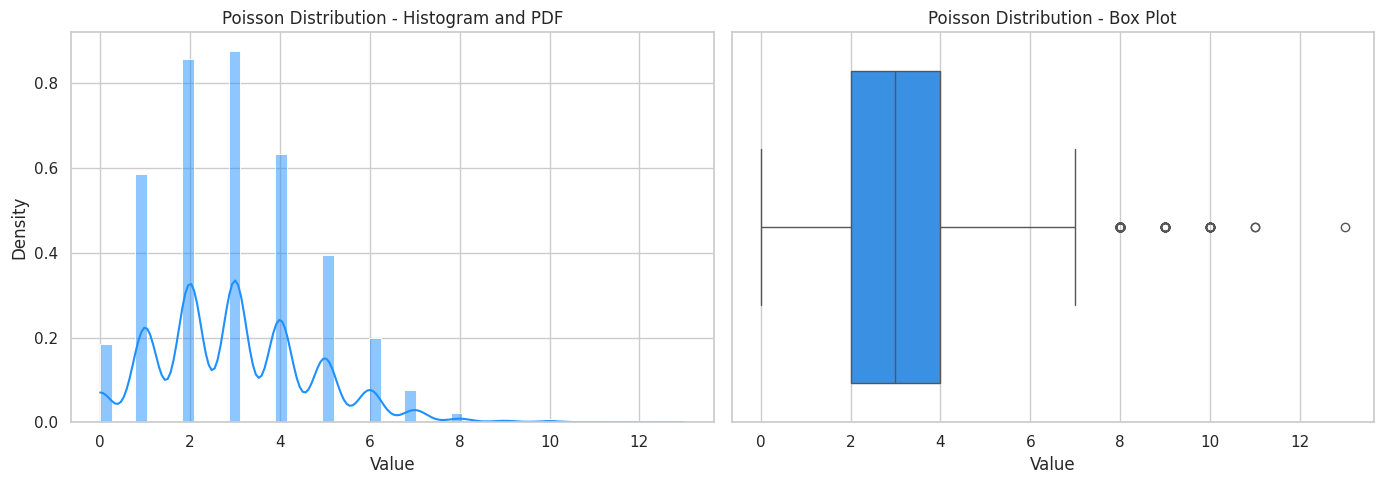

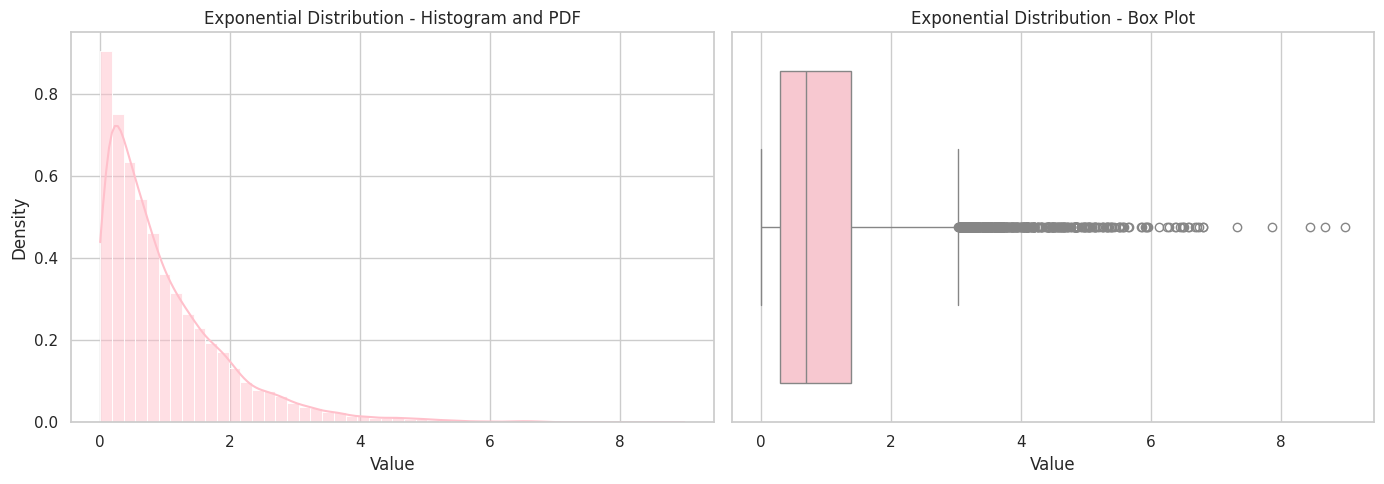

In [10]:
plot_distribution(distributions["Poisson"], "Poisson", "dodgerblue")
plot_distribution(distributions["Exponential"], "Exponential", "pink")

### **3.3 Visualize Log-normal Distribution**

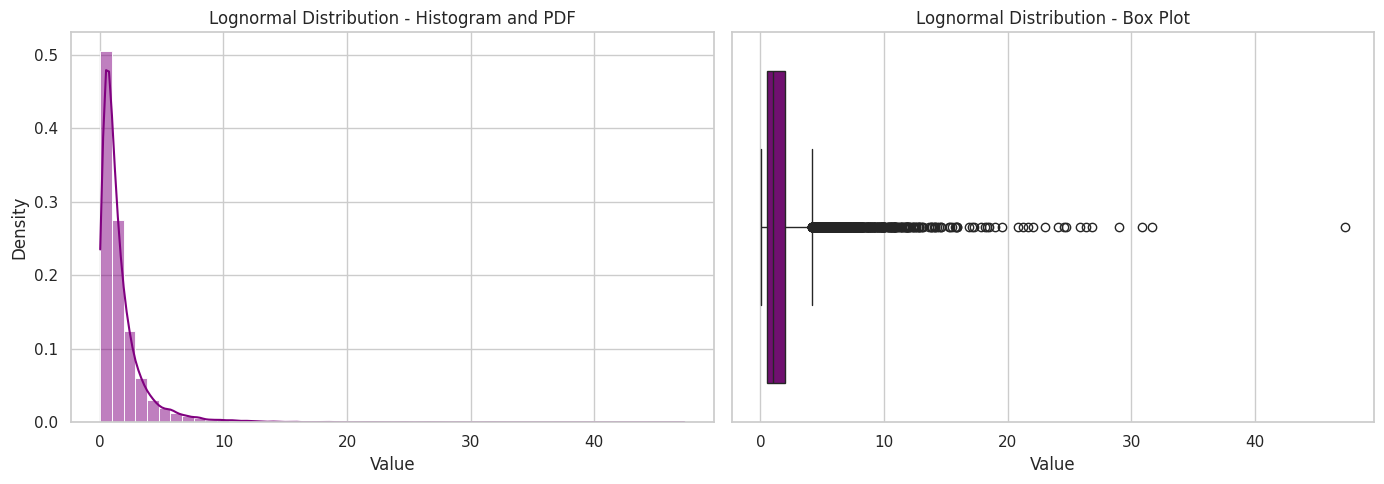

In [9]:
plot_distribution(distributions["Lognormal"], "Lognormal", "purple")

## **4. Comparative Analysis (Answers)**
We can deduce the real-world applications and shapes of these distributions based on our statistical properties (Skewness, Kurtosis) and visualizations.

1. Which distribution is symmetric?
   - Normal and Uniform distributions are symmetric. (Their skewness is close to 0).

2. Which is right-skewed?
   - Exponential, Log-normal, and Poisson distributions are right-skewed. (They have positive skewness, with Log-normal having a very heavy right tail).

3. Which resembles real salary data?
   - Log-normal distribution. Income and salaries cannot be negative and usually have a large cluster at the lower/middle end with a long right tail of very high earners.

4. Which can model customer arrivals?
   - Poisson distribution (for the number of arrivals in a fixed time) and Exponential distribution (for the time between customer arrivals).

5. Which is suitable for diffusion models?
   - Normal (Gaussian) distribution. Forward diffusion processes in AI progressively add Gaussian noise to images until they become pure Normal distribution noise.